In [ ]:
import numpy as np
from lumicks import pylake
import glob
import pathlib
import matplotlib.colors as mcolors

# select the folder with h5 files
directory_h = r"D:\Sushil\DnaB\unwinding\60bp_24bp overhang"
d_current = r"/"
directory_save = directory_h + d_current
filename = glob.glob(directory_save+'*Kymograph 16.h5')
file = pylake.File(filename[0])
name, kymo = file.kymos.popitem()
import matplotlib.pyplot as plt
from IPython import get_ipython

plt.rcParams['font.size'] = 12
colors = [(1,0,0,c) for c in np.linspace(0,1,100)]
cmapred = mcolors.LinearSegmentedColormap.from_list('mycmap', colors, N=5)
colors = [(0,1,0,c) for c in np.linspace(0,1,100)]
cmapgreen = mcolors.LinearSegmentedColormap.from_list('mycmap', colors, N=5)
colors = [(0,0,1,c) for c in np.linspace(0,1,100)]
cmapblue = mcolors.LinearSegmentedColormap.from_list('mycmap', colors, N=5)

# newpth = directory_h+d_current+"/images/"
# pathlib.Path(newpth).mkdir(parents=True, exist_ok=True)

# get_ipython().run_line_magic('matplotlib', 'qt5')
# plt.ioff()
# print("found {} files in folder".format(len(files)))
file = pylake.File(filename[0])
name, kymo = file.kymos.popitem()

data =kymo["0s":"1600s"].crop_by_distance(0,25)#.calibrate_to_kbp(48502) #this will crop by time(x-axis)
green = data.get_image(channel='green')
red = data.get_image(channel='red')
blue = data.get_image(channel='blue')

linetime = data.line_time_seconds
pixelsize=data.pixelsize_um
#print(pixelsize)
extnt = [0,green.shape[1]*linetime,green.shape[0]*pixelsize[0],0]
#extnt = [0,green.shape[1]*linetime,green.shape[0]*pixelsize[0],0]
%matplotlib widget
plt.figure(dpi=100)
ax=plt.gca()
ax.set_facecolor("black")

plt.imshow(red,cmap=cmapred,vmin=0,vmax=8,extent=extnt,aspect='auto')
#plt.imshow(green,cmap=cmapgreen,vmin=10,vmax=45,extent=extnt,aspect=45)
#plt.imshow(blue,cmap=cmapblue,vmin=0,vmax=10,alpha=0.75,extent=extnt,aspect='auto')
#plt.yscale(0.1)

plt.xlabel("Time (s)")
plt.ylabel("Distance (um)")
#plt.tight_layout()
#plt.savefig(directory_save+'red_nt.pdf')
#tt = d_current[0:6]+"-kymo-"+key
#plt.title('Srs2_100bp_blunt')
#cairosvg.svg2svg("input.png", "output.svg")
#plt.savefig(directory_save+'cropped2'+'.svg')
plt.show()

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

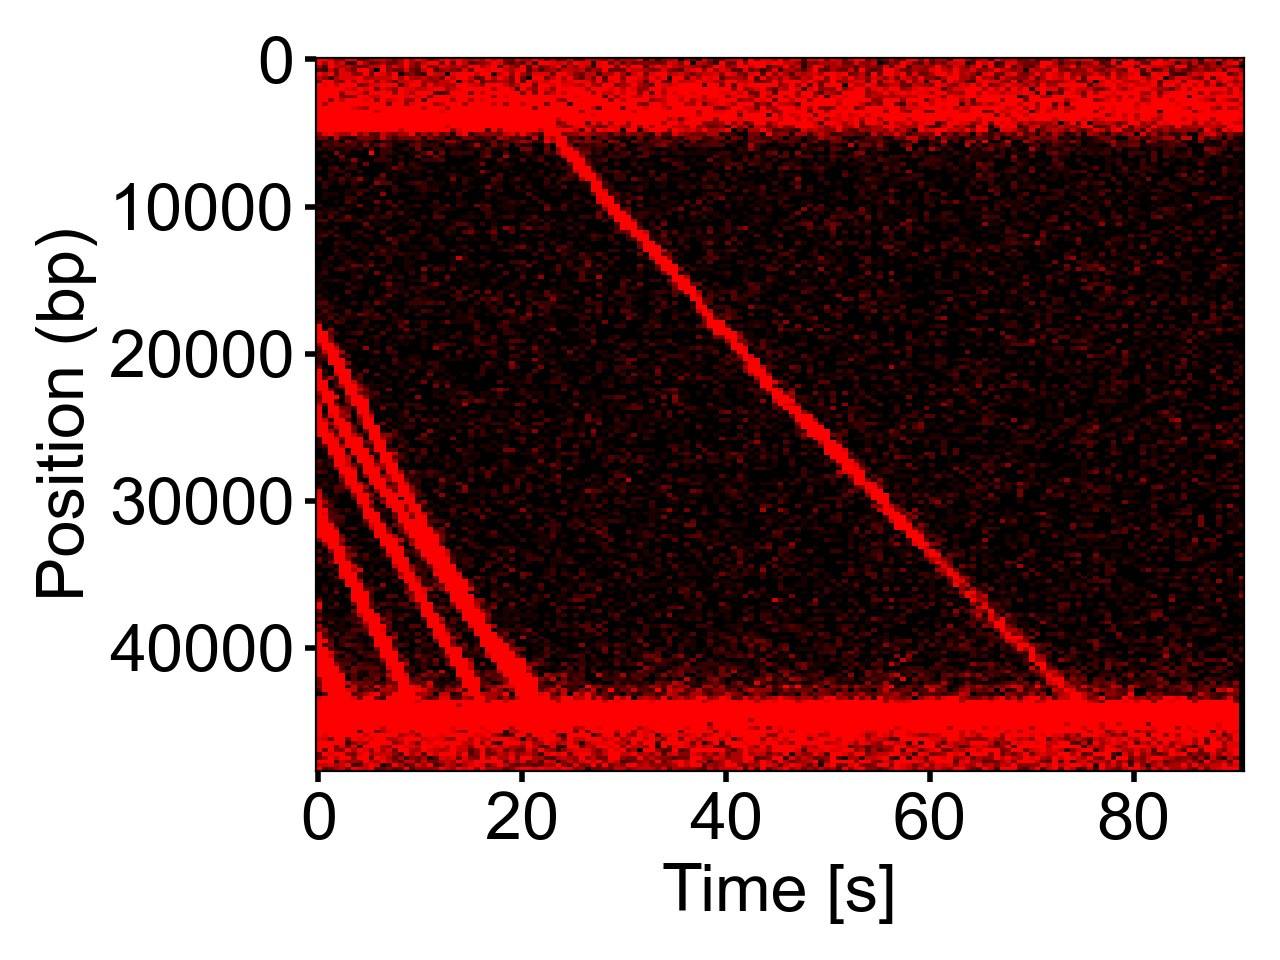

In [2]:
data =kymo["0s":"820s"].crop_by_distance(0,25).calibrate_to_kbp(48502) #this will crop by time(x-axis), 
#distance(y-axis) and then convert y-axis to kbp.It is essential that you look numbers carefully in previous kymos otherwise your 
#velocity will be off
%matplotlib widget
plt.figure(dpi=200)
data.plot(channel='red', aspect="auto",vmin=1,vmax=10)
#plt.title("")
#plt.ylabel('Position bp')
plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
plt.ylabel('Position (bp)',fontsize=24,fontname="Arial")
plt.tick_params(axis="x", direction="out", length=4, width=2)
plt.tick_params(axis="y", direction="out", length=4, width=2)
plt.xticks(fontsize=20, fontname="Arial")
plt.yticks(fontsize=20,fontname="Arial")
x_tick_labels = plt.gca().get_xticklabels()
y_tick_labels = plt.gca().get_yticklabels()
font_properties = {'family': 'arial', 'size':24}
for label in x_tick_labels:
    label.set_fontproperties(font_properties)
for label in y_tick_labels:
    label.set_fontproperties(font_properties)
plt.title('')
plt.tight_layout()
plt.show()
#data.plot_with_force("2x", "red", adjustment=lk.ColorAdjustment(0, 15))

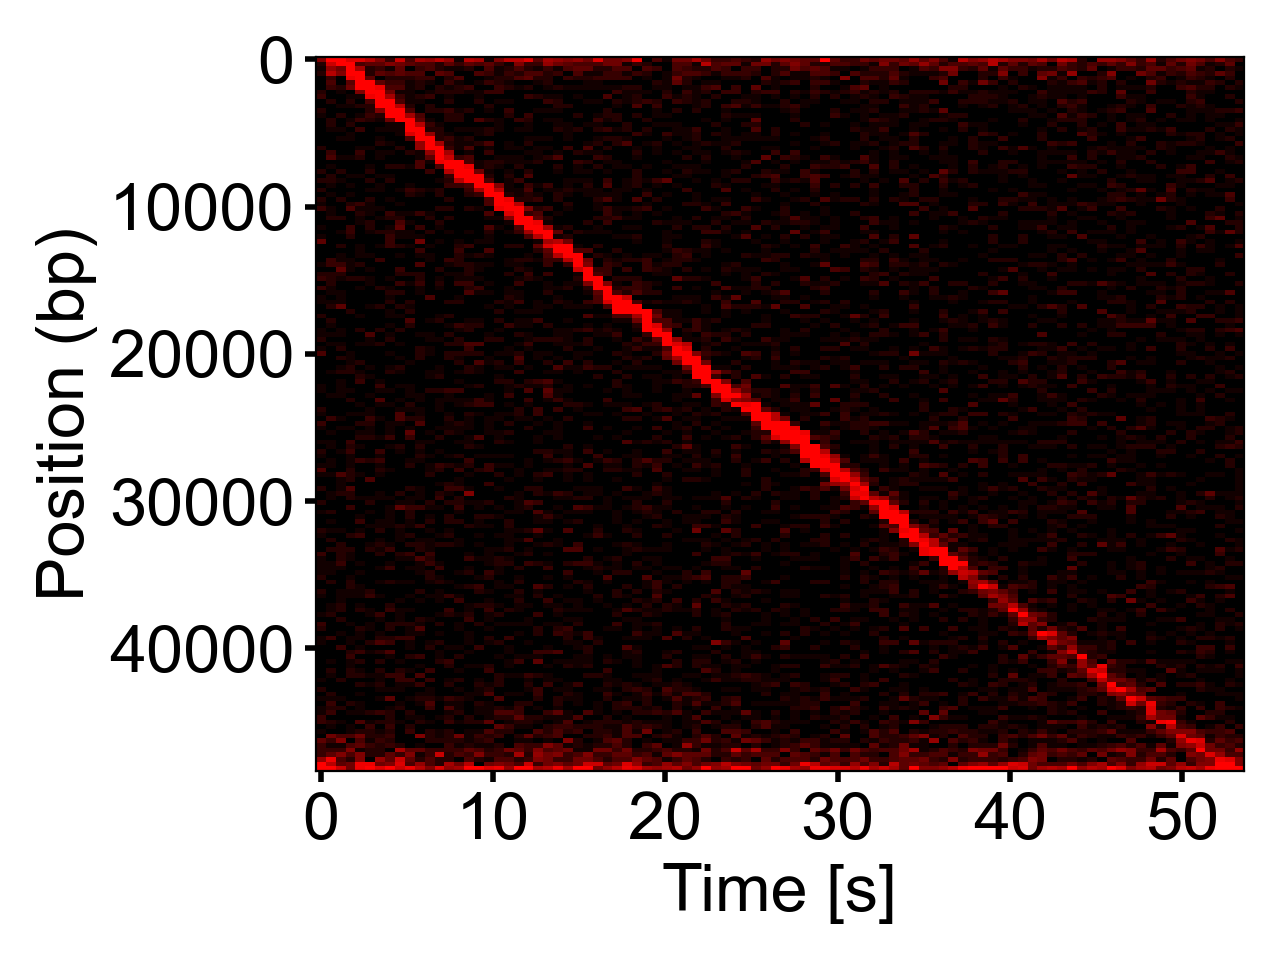

In [3]:
data =kymo["21.87s":"75.56s"].crop_by_distance(1.91,17.12).calibrate_to_kbp(48502) #this will crop by time(x-axis), 
#distance(y-axis) and then convert y-axis to kbp.It is essential that you look numbers carefully in previous kymos otherwise your 
#velocity will be off
%matplotlib widget
plt.figure(dpi=200)
data.plot(channel='red', aspect="auto",vmin=1,vmax=15)
#plt.title("")
#plt.ylabel('Position bp')
plt.xlabel('Time [s]',fontsize=24,fontname="Arial")
plt.ylabel('Position (bp)',fontsize=24,fontname="Arial")
plt.tick_params(axis="x", direction="out", length=4, width=2)
plt.tick_params(axis="y", direction="out", length=4, width=2)
plt.xticks(fontsize=20, fontname="Arial")
plt.yticks(fontsize=20,fontname="Arial")
x_tick_labels = plt.gca().get_xticklabels()
y_tick_labels = plt.gca().get_yticklabels()
font_properties = {'family': 'arial', 'size':24}
for label in x_tick_labels:
    label.set_fontproperties(font_properties)
for label in y_tick_labels:
    label.set_fontproperties(font_properties)
plt.title('')
plt.tight_layout()
plt.show()
#data.plot_with_force("2x", "red", adjustment=lk.ColorAdjustment(0, 15))

In [7]:
%matplotlib widget
kymowidget = pylake.KymoWidgetGreedy(data, 'red',vmin=1,vmax=15,axis_aspect_ratio=2,min_length=3, pixel_threshold=5,track_width=2, window=6, sigma=1.5)
plt.ylabel('Position [bp]')
plt.xlabel('Time [s]')

Text(0.5, 32.99999999999999, 'Time [s]')

KymoTrackGroup(N=1)


C:\Users\ch250582\AppData\Local\Temp\ipykernel_9236\997562224.py:18: RuntimeWarning: Prior to version 1.1.0 the method `sample_from_image` had a bug that assumed the origin of a pixel to be at the edge rather than the center of the pixel. Consequently, the sampled window could frequently be off by one pixel. To get the correct behavior and silence this warning, specify `correct_origin=True`. The old (incorrect) behavior is maintained until the next major release to ensure backward compatibility. To silence this warning use `correct_origin=False`.
  plt.plot(longest_track.seconds, longest_track.sample_from_image(num_pixels=3))


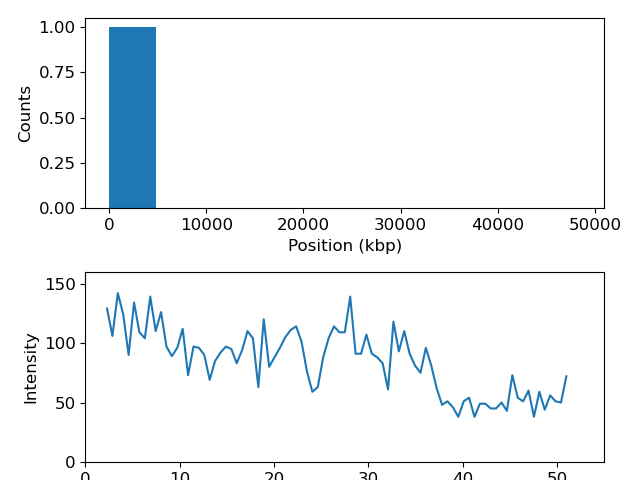

In [18]:
tracks = kymowidget.tracks #this gives you the kymolines,it should match the lines you see above.
#If not, go back above and remove tiny traces
print(tracks)
# c=directory_save+b+'.csv'
# tracks.save(c)
#next, we will extract the time and p
# ixel size  for further calculations
#len(lines)
longest_track_idx = np.argmax([len(track) for track in tracks])
longest_track = tracks[longest_track_idx]
%matplotlib widget
plt.figure(dpi=100)
plt.subplot(2,1,1)
tracks.plot_binding_histogram(kind="binding")
plt.title('')
plt.tight_layout()
plt.subplot(2,1,2)
plt.plot(longest_track.seconds, longest_track.sample_from_image(num_pixels=3))
plt.xlim(0,55)
plt.ylim(0,160)
plt.xlabel('Time (s)')
plt.ylabel('Intensity')
#plt.tight_layout()
plt.show()
